# Predictive Maintenance for Component X Failures in Heavy-Duty Scania Trucks: An Interpretable Machine Learning Approach

## A Non-Deep Learning Approach with Interpretability

### Project Overview
This notebook implements an interpretable predictive maintenance pipeline for SCANIA trucks. The goal is to predict component failures using operational data while maintaining model interpretability. We follow the CRISP-DM methodology:

1.  **Business Understanding:** Minimize unplanned downtime costs. Because on-road maintenance is quite expensive and causes supply chain disruptions.
2.  **Data Understanding:** [SCANIA Component X Dataset (2025)](https://researchdata.se/en/catalogue/dataset/2024-34/2).
3.  **Data Preparation:** Decumulation of counters, histogram flattening, and temporal feature engineering for ML model.
4.  **Modeling:** Gradient Boosting (XGBoost) with imbalance handling (SMOTE).
5.  **Evaluation:** Recall, F1-Score, and SHAP explainability.

### Dataset Structure
The dataset has three main files/structures:
- **Operational Readouts:** Cumulative counters and histogram bins over time.
- **Specifications:** Categorical truck data.
- **Labels:** Binary classification (0: Healthy, 1: Failure-Prone).

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, f1_score, precision_score
from imblearn.over_sampling import SMOTE
import warnings

# Settings for the plots
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

In [2]:
# Set the SEED value for reproducibility
SEED = 42
import random

random.seed(SEED)
np.random.seed(SEED)

## 1. Data Loading and Preprocessing

In [3]:
# Define dataset file paths
DATASET_DIR_PATH = "SCANIA Dataset/data/"

# Load Training Data
train_operational_readout_DF = pd.read_csv(DATASET_DIR_PATH + "train_operational_readouts.csv")
train_specifications_DF = pd.read_csv(DATASET_DIR_PATH + "train_specifications.csv")
train_labels_DF = pd.read_csv(DATASET_DIR_PATH + "train_tte.csv")

In [4]:
# Load Test Data
test_operational_readout_DF = pd.read_csv(DATASET_DIR_PATH + "test_operational_readouts.csv")
test_specifications_DF = pd.read_csv(DATASET_DIR_PATH + "test_specifications.csv")
test_labels_DF = pd.read_csv(DATASET_DIR_PATH + "test_labels.csv")

In [5]:
print(f"Train Operational Readout DataFrame Shape: {train_operational_readout_DF.shape}")
print(f"Test Operational Readout DataFrame Shape: {test_operational_readout_DF.shape}")

Train Operational Readout DataFrame Shape: (1122452, 107)
Test Operational Readout DataFrame Shape: (198140, 107)


- The training set contains **1,122,452 observations (≈1.12 million)**, and
- The test set contains **198,140 observations (≈0.20 million)**.

In [6]:
# View first 5 samples
train_operational_readout_DF.head()

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,167_4,167_5,167_6,167_7,167_8,167_9,309_0,272_0,272_1,272_2,272_3,272_4,272_5,272_6,272_7,272_8,272_9,835_0,370_0,291_0,291_1,291_2,291_3,291_4,291_5,291_6,291_7,291_8,291_9,291_10,158_0,158_1,158_2,158_3,158_4,158_5,158_6,158_7,158_8,158_9,100_0,459_0,459_1,459_2,459_3,459_4,459_5,459_6,459_7,459_8,459_9,459_10,459_11,459_12,459_13,459_14,459_15,459_16,459_17,459_18,459_19,397_0,397_1,397_2,397_3,397_4,397_5,397_6,397_7,397_8,397_9,397_10,397_11,397_12,397_13,397_14,397_15,397_16,397_17,397_18,397_19,397_20,397_21,397_22,397_23,397_24,397_25,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
0,0,11.2,167985.0,10787.0,7413813.0,2296.0,4110.0,1296420.0,1628265.0,630345.0,1269525.0,4772940.0,2706706.0,222225.0,6240.0,0.0,70.0,1435083.0,857662.0,384579.0,668642.0,7239843.0,398490.0,3887.0,0.0,0.0,0.0,8036751.0,0.0,1227.0,555.0,463.0,925.0,468.0,225.0,535.0,516.0,492.0,729.0,66.0,97056.0,2690052.0,2945268.0,788437.0,687480.0,595164.0,491232.0,532932.0,809628.0,505693.0,858410.0,203.676778,111.911500,147.265389,200.479944,230.306278,277.722417,315.748806,372.164528,864.246250,920.881111,637.901639,744.618944,880.866889,1272.323972,1847.623667,940.785694,2.900083,0.208444,0.056417,0.058444,446956.0,411420.0,203024.0,26636.0,29156.0,7616.0,449537.0,233352.0,139920.0,12648.0,2813.0,224.0,53161.0,178881.0,138250.0,13328.0,3581.0,88.0,16361.0,131601.0,116541.0,13506.0,2856.0,48.0,6337.0,105412.0,95728.0,15609.0,1984.0,8.0,784.0,150228.0,261904.0,93172.0,17874.0,452.0
1,0,11.4,167985.0,10787.0,7413813.0,2296.0,4111.0,1302855.0,1628265.0,630345.0,1269526.0,4772940.0,2706706.0,222225.0,6240.0,0.0,70.0,1440661.0,857662.0,384579.0,668642.0,7239843.0,398490.0,3887.0,0.0,0.0,0.0,8040811.0,0.0,1230.0,558.0,463.0,925.0,469.0,226.0,535.0,516.0,493.0,729.0,66.0,97056.0,2693100.0,2947368.0,788437.0,687480.0,595164.0,491232.0,532932.0,809628.0,505693.0,860571.0,204.256750,112.924250,147.265389,201.479944,230.306278,277.722417,315.748806,372.164528,864.246250,920.881111,637.901639,745.618944,880.866889,1272.323972,1847.623667,940.785694,2.900083,0.208444,0.056417,0.058444,446964.0,411420.0,203027.0,26638.0,29157.0,7616.0,451193.0,233354.0,139920.0,12649.0,2813.0,224.0,53210.0,178883.0,138252.0,13328.0,3582.0,88.0,16368.0,131601.0,116542.0,13507.0,2856.0,48.0,6339.0,105413.0,95729.0,15610.0,1984.0,8.0,784.0,150228.0,261905.0,93172.0,17874.0,452.0
2,0,19.6,331635.0,14525.0,13683604.0,2600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,1787736.0,1133132.0,598351.0,1167062.0,12314224.0,460240.0,3887.0,0.0,0.0,0.0,12777022.0,0.0,2136.0,954.0,850.0,1420.0,722.0,412.0,880.0,666.0,586.0,1143.0,162.0,181632.0,4249020.0,4630440.0,1539133.0,1421172.0,1039764.0,749472.0,740724.0,995796.0,574045.0,1379191.0,321.671972,157.312500,193.792833,263.577611,310.711861,366.149250,415.642472,484.391167,1146.111611,1286.536333,900.062917,1123.232556,1449.545611,2140.037472,5046.748278,1151.010139,3.320194,0.218806,0.056778,0.058444,756665.0,647348.0,286811.0,30967.0,31213.0,7745.0,633790.0,423395.0,271940.0,16190.0,3573.0,232.0,75038.0,352791.0,327992.0,17325.0,4451.0,92.0,24028.0,234737.0,216619.0,17000.0,3476.0,48.0,12055.0,167693.0,142900.0,19263.0,2441.0,12.0,1420.0,204832.0,313485.0,106464.0,19306.0,452.0
3,0,20.2,354975.0,15015.0,14540449.0,2616.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,1824409.0,1166074.0,634595.0,1233908.0,13275730.0,466753.0,3887.0,0.0,0.0,0.0,13612083.0,0.0,2218.0,1014.0,892.0,1471.0,749.0,425.0,901.0,702.0,589.0,1197.0,174.0,193728.0,4462548.0,4988028.0,1696022.0,1565484.0,1112544.0,789228.0,774588.0,1015104.0,576901.0,1428606.0,331.479028,162.731639,198.104472,269.712889,320.087333,377.478667,425.901361,495.749583,1173.882583,1323.460972,923.099361,1161.893139,1501.973944,2208.782833,5587.856667,1160.593833,3.336417,0.218806,0.056778,0.058444,812577.0,686860.0,302955.0,31927.0,31488.0,7749.0,651902.0,478279.0,292109.0,16755.0,3753.0,232.0,77118.0,39408

It is important to understand the dataset. So, there are some properties of each column that we need to understand:

1. `vehicle_id`: This is the truck's unique ID. It allows us to group rows together to see the history of one specific vehicle.
2. `time_step`: It indicates the time when the sensor readings were read in relation to the specific vehicle's start of operation. In other words, `time_step` represents the number of time units the vehicle and Component X have been in use.
4. `14 Variables`: There are 14 different Types of Measurements (like Temperature, Pressure, Voltage, etc.). Each variable can have one or multiple bins described by an index.
   
   Instead of giving us thousands of separate sensor readings, Scania grouped them into "Activity Buckets" (Bins). Each variable (like Variable 1234) is split into several columns (1234_0, 1234_1, etc.) representing a range from "Low" to "High." The number in each column tells us how much time the truck spent in that specific range during its operation. This allows our model to easily see if a truck is "working too hard" (spending too much time in high-value buckets), which is a clear sign that a part is about to break.

In [7]:
# View first 5 samples
train_specifications_DF.head()

,vehicle_id,Spec_0,Spec_1,Spec_2,Spec_3,Spec_4,Spec_5,Spec_6,Spec_7
0,0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0
1,2,Cat0,Cat1,Cat1,Cat0,Cat0,Cat0,Cat0,Cat1
2,3,Cat0,Cat1,Cat1,Cat1,Cat0,Cat0,Cat0,Cat1
3,4,Cat0,Cat0,Cat2,Cat1,Cat0,Cat0,Cat0,Cat1
4,5,Cat0,Cat2,Cat2,Cat0,Cat0,Cat0,Cat0,Cat1


In [8]:
# View first 5 samples
train_labels_DF.head()

,vehicle_id,length_of_study_time_step,in_study_repair
0,0,510.0,0
1,2,281.8,0
2,3,293.4,0
3,4,210.0,0
4,5,360.4,0


If `in_study_repair` is set to 1 --> it means that Component X was repaired (for the first time)
`length_of_study_time_step` time units after the start of operation of the vehicle with Component X (factory
mounted).

On the other hand, if `in_study_repair` is set to 0 --> no repair event occurred during the first
`length_of_study_time_step` time units of operation.

# 2 Missing Values

The dataset contains **missing values** as certain sensors did not record a reading at every time step. So, for all such instances, we have `NULL` values in the dataset. Let's check the NULL values.

In [9]:
# ----------------- Missing Value Analysis ----------------------

# Count NULL values
missing_values_counts = train_operational_readout_DF.isnull().sum()
missing_values_percentage = (train_operational_readout_DF.isnull().sum() / len(train_operational_readout_DF)) * 100
missing_DF = pd.DataFrame({"Missing Count": missing_values_counts,
                           "Missing %": missing_values_percentage
                          }).query("`Missing Count` > 0").sort_values("Missing %", ascending=False)


In [10]:
# Check some stats on missing values
print(f"Total columns in train operational readout DataFrame: {train_operational_readout_DF.shape[1]}")
print(f"Columns WITH missing values: {len(missing_DF)}")
print(f"Columns WITHOUT missing values: {train_operational_readout_DF.shape[1] - len(missing_DF)}")
print("\n")
print(f"Total number of NULL value cells: {train_operational_readout_DF.isnull().sum().sum()}")
print(f"Overall missing rate: {round(((train_operational_readout_DF.isnull().sum().sum() / train_operational_readout_DF.size) * 100),3)}%")

Total columns in train operational readout DataFrame: 107
Columns WITH missing values: 104
Columns WITHOUT missing values: 3


Total number of NULL value cells: 354634
Overall missing rate: 0.295%


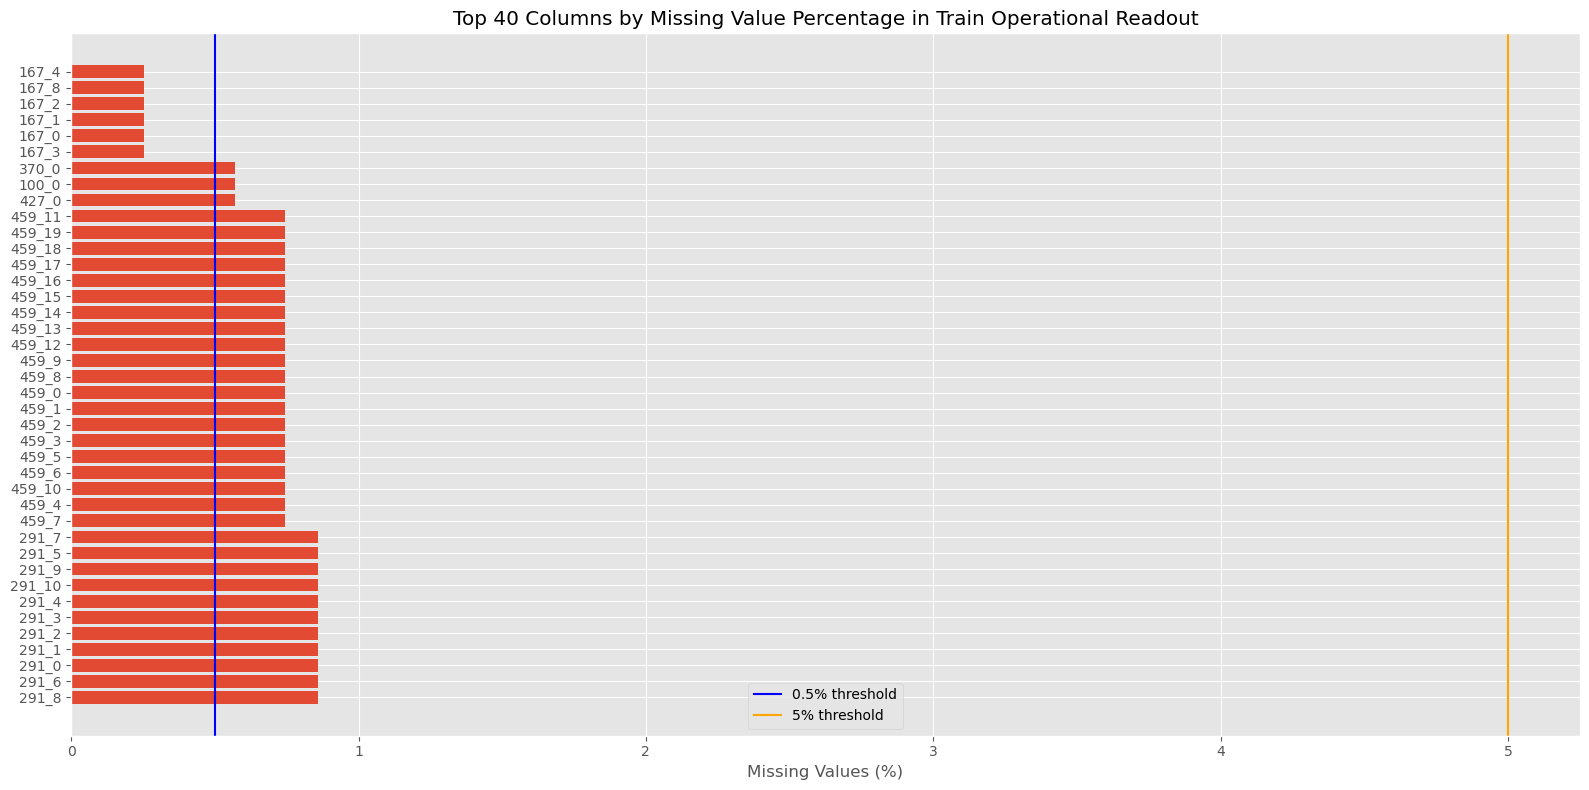

In [11]:
# Visualize Missing Value Distribution
fig, ax = plt.subplots(figsize=(16, 8))

# Select only the top 40 missing value columns
top_missing_DF = missing_DF.head(40)
ax.barh(top_missing_DF.index, top_missing_DF['Missing %'])
ax.set_xlabel('Missing Values (%)')
ax.set_title('Top 40 Columns by Missing Value Percentage in Train Operational Readout')

# Plot some threshold lines for better inspection
ax.axvline(x=0.5, color='blue', label='0.5% threshold')
ax.axvline(x=5, color='orange', label='5% threshold')
ax.legend()

plt.tight_layout()
plt.savefig('Plots/missing_values_analysis.png', dpi=1200, bbox_inches='tight') #SOS
plt.show()

The missing values plot shows the top 40 features with the highest percentages of NULL values. It is clear from the plot that the percentage of missing values for all columns is less than 1%.

## 2.1 Solution for NULL values

We have possible solutions to handle NULL values:
1. **Zero Imputation**: Replace NULL values with 0.
   
   > It is not a good approach because the ML models would imply that the sensor gave a 0 reading, and our accuracy might suffer.

2. **Mean/Median Imputation**: Replace NULL with column mean.

   > This strategy ignores temporal order and thus is not a good strategy.

3. **Forward-Fill (ffill)**: Carry the last known value forward.

   > It is a safe approach for the cumulative counters, and it would signal the model that no new reading arrived, and the total value has not changed.

   > If a truck's counter reads a value `y` at step 5 and no reading was transmitted at step 6. Then, the most appropriate assumption is that the counter remained at value `y` (i.e., the component was idle or the signal was lost).

### 2.1.1 Missingness Indicators:

In addition to these imputations, we combine them with **Missingness Indicators** strategy. That is, for every column `Col_x` that contains NULL values, a new binary feature `Col_x_is_missing` is created, such that:

- Value = 0: The original data was present.
- Value = 1: The value was missing and has been imputed.

In [12]:
# Sort the operational data based on vehicle_id and the time step
train_operational_readout_DF_sorted = train_operational_readout_DF.sort_values(by=['vehicle_id', 'time_step'])
test_operational_readout_DF_sorted = test_operational_readout_DF.sort_values(by=['vehicle_id', 'time_step'])

# Store the names of the features
feature_columns = [c for c in train_operational_readout_DF_sorted.columns if c not in ['vehicle_id', 'time_step']]

# Forward-fill within each truck to handle intermittent sensor gaps
# Create Missingness Indicators BEFORE imputing
for col in feature_columns:
    if train_operational_readout_DF_sorted[col].isnull().any() or test_operational_readout_DF_sorted[col].isnull().any():
        train_operational_readout_DF_sorted[f'{col}_is_missing'] = train_operational_readout_DF_sorted[col].isnull().astype(int)
        test_operational_readout_DF_sorted[f'{col}_is_missing'] = test_operational_readout_DF_sorted[col].isnull().astype(int)

# Forward-fill within each truck to handle intermittent sensor gaps
train_operational_readout_DF_sorted[feature_columns] = train_operational_readout_DF_sorted.groupby('vehicle_id')[feature_columns].ffill()
test_operational_readout_DF_sorted[feature_columns] = test_operational_readout_DF_sorted.groupby('vehicle_id')[feature_columns].ffill()

# Check for NULL values after forward-fill
print("Number of NULL values in 'train operational readout' after applying forward-fill:",train_operational_readout_DF_sorted.isnull().sum().sum())

Number of NULL values in 'train operational readout' after applying forward-fill: 18266


In [13]:
# These NULL values are for those vehicles whose initial time_step's reading was missing and that was carried forward
# Let us check to be 100% sure
rows_with_null_values = train_operational_readout_DF_sorted[
    train_operational_readout_DF_sorted.isnull().any(axis=1)
]

print("Number of rows with NULL values:", len(rows_with_null_values))

Number of rows with NULL values: 1217


In [14]:
# Let's view first 5 samples
rows_with_null_values.head()

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,167_4,167_5,167_6,167_7,167_8,167_9,309_0,272_0,272_1,272_2,272_3,272_4,272_5,272_6,272_7,272_8,272_9,835_0,370_0,291_0,291_1,291_2,291_3,291_4,291_5,291_6,291_7,291_8,291_9,291_10,158_0,158_1,158_2,158_3,158_4,158_5,158_6,158_7,158_8,158_9,100_0,459_0,459_1,459_2,459_3,459_4,459_5,459_6,459_7,459_8,459_9,459_10,459_11,459_12,459_13,459_14,459_15,459_16,459_17,459_18,459_19,397_0,397_1,397_2,397_3,397_4,397_5,397_6,397_7,397_8,397_9,397_10,397_11,397_12,397_13,397_14,397_15,397_16,397_17,397_18,397_19,397_20,397_21,397_22,397_23,397_24,397_25,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35,666_0_is_missing,427_0_is_missing,837_0_is_missing,167_0_is_missing,167_1_is_missing,167_2_is_missing,167_3_is_missing,167_4_is_missing,167_5_is_missing,167_6_is_missing,167_7_is_missing,167_8_is_missing,167_9_is_missing,309_0_is_missing,272_0_is_missing,272_1_is_missing,272_2_is_missing,272_3_is_missing,272_4_is_missing,272_5_is_missing,272_6_is_missing,272_7_is_missing,272_8_is_missing,272_9_is_missing,835_0_is_missing,370_0_is_missing,291_0_is_missing,291_1_is_missing,291_2_is_missing,291_3_is_missing,291_4_is_missing,291_5_is_missing,291_6_is_missing,291_7_is_missing,291_8_is_missing,291_9_is_missing,291_10_is_missing,158_0_is_missing,158_1_is_missing,158_2_is_missing,158_3_is_missing,158_4_is_missing,158_5_is_missing,158_6_is_missing,158_7_is_missing,158_8_is_missing,158_9_is_missing,100_0_is_missing,459_0_is_missing,459_1_is_missing,459_2_is_missing,459_3_is_missing,459_4_is_missing,459_5_is_missing,459_6_is_missing,459_7_is_missing,459_8_is_missing,459_9_is_missing,459_10_is_missing,459_11_is_missing,459_12_is_missing,459_13_is_missing,459_14_is_missing,459_15_is_missing,459_16_is_missing,459_17_is_missing,459_18_is_missing,459_19_is_missing,397_0_is_missing,397_1_is_missing,397_2_is_missing,397_3_is_missing,397_4_is_missing,397_5_is_missing,397_6_is_missing,397_7_is_missing,397_8_is_missing,397_9_is_missing,397_10_is_missing,397_11_is_missing,397_12_is_missing,397_13_is_missing,397_14_is_missing,397_15_is_missing,397_16_is_missing,397_17_is_missing,397_18_is_missing,397_19_is_missing,397_20_is_missing,397_21_is_missing,397_22_is_missing,397_23_is_missing,397_24_is_missing,397_25_is_missing,397_26_is_missing,397_27_is_missing,397_28_is_missing,397_29_is_missing,397_30_is_missing,397_31_is_missing,397_32_is_missing,397_33_is_missing,397_34_is_missing,397_35_is_missing
276,4,3.8,210915.0,21371.0,9930734.0,9560.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,266.0,1559792.0,936923.0,331760.0,636077.0,11006190.0,831675.0,3159.0,0.0,0.0,0.0,11197611.0,0.0,1599.0,552.0,603.0,1221.0,663.0,372.0,862.0,597.0,828.0,1116.0,60.0,147456.0,3176124.0,4205244.0,990708.0,930913.0,932604.0,806136.0,656688.0,994992.0,1287361.0,1373990.0,321.305167,203.614250,288.045583,410.986750,486.641444,584.559361,715.624250,767.795361,1677.445583,1781.738694,929.835056,1003.348250,1215.099833,1650.392500,2011.951000,1703.003167,2.729389,0.108861,0.000000,0.00000,614549.0,490680.0,313956.0,56161.0,39554.0,7992.0,698528.0,165572.0,234481.0,25360.0,8493.0,292.0,74737.0,118417.0,321244.0,32396.0,12268.0,248.0,24018.0,101333.0,287946.0,31325.0,10538.0,176.0,10317.0,83399.0,195169.0,29329.0,7700.0,56.0,1305.0,143769.0,388012.0,134709.0,44692.0,712.0,0,0,0,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
277,4,45.0,266085.0,24052.0,12096470.0,11696.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,322.0,1961986.0,1156259.0,396942.0,753259.0,13185718.0,1073605.0,4459.0,0.0,0.0,0.0,13558491.0,0.0,1930.0,705.0,753.0,1479.0,792.0,423.0,1018.0,699.0,870.0,1263.0,90.0,205189.0,3901704.0,5036833.0,1327440.0,1257001.0,1143444.0,953652.0,754572.0,1124616.0,1402225.0,1631175.0,390.695306,240.717667,335.431833,477.872889,561.093444,653.369722,790.237083,85

In [15]:
# Let us view the samples from index 270 to 300 to verify that for vehicle_id 4's initial time_step value was NULL or not
train_operational_readout_DF_sorted.iloc[270:300]

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,167_4,167_5,167_6,167_7,167_8,167_9,309_0,272_0,272_1,272_2,272_3,272_4,272_5,272_6,272_7,272_8,272_9,835_0,370_0,291_0,291_1,291_2,291_3,291_4,291_5,291_6,291_7,291_8,291_9,291_10,158_0,158_1,158_2,158_3,158_4,158_5,158_6,158_7,158_8,158_9,100_0,459_0,459_1,459_2,459_3,459_4,459_5,459_6,459_7,459_8,459_9,459_10,459_11,459_12,459_13,459_14,459_15,459_16,459_17,459_18,459_19,397_0,397_1,397_2,397_3,397_4,397_5,397_6,397_7,397_8,397_9,397_10,397_11,397_12,397_13,397_14,397_15,397_16,397_17,397_18,397_19,397_20,397_21,397_22,397_23,397_24,397_25,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35,666_0_is_missing,427_0_is_missing,837_0_is_missing,167_0_is_missing,167_1_is_missing,167_2_is_missing,167_3_is_missing,167_4_is_missing,167_5_is_missing,167_6_is_missing,167_7_is_missing,167_8_is_missing,167_9_is_missing,309_0_is_missing,272_0_is_missing,272_1_is_missing,272_2_is_missing,272_3_is_missing,272_4_is_missing,272_5_is_missing,272_6_is_missing,272_7_is_missing,272_8_is_missing,272_9_is_missing,835_0_is_missing,370_0_is_missing,291_0_is_missing,291_1_is_missing,291_2_is_missing,291_3_is_missing,291_4_is_missing,291_5_is_missing,291_6_is_missing,291_7_is_missing,291_8_is_missing,291_9_is_missing,291_10_is_missing,158_0_is_missing,158_1_is_missing,158_2_is_missing,158_3_is_missing,158_4_is_missing,158_5_is_missing,158_6_is_missing,158_7_is_missing,158_8_is_missing,158_9_is_missing,100_0_is_missing,459_0_is_missing,459_1_is_missing,459_2_is_missing,459_3_is_missing,459_4_is_missing,459_5_is_missing,459_6_is_missing,459_7_is_missing,459_8_is_missing,459_9_is_missing,459_10_is_missing,459_11_is_missing,459_12_is_missing,459_13_is_missing,459_14_is_missing,459_15_is_missing,459_16_is_missing,459_17_is_missing,459_18_is_missing,459_19_is_missing,397_0_is_missing,397_1_is_missing,397_2_is_missing,397_3_is_missing,397_4_is_missing,397_5_is_missing,397_6_is_missing,397_7_is_missing,397_8_is_missing,397_9_is_missing,397_10_is_missing,397_11_is_missing,397_12_is_missing,397_13_is_missing,397_14_is_missing,397_15_is_missing,397_16_is_missing,397_17_is_missing,397_18_is_missing,397_19_is_missing,397_20_is_missing,397_21_is_missing,397_22_is_missing,397_23_is_missing,397_24_is_missing,397_25_is_missing,397_26_is_missing,397_27_is_missing,397_28_is_missing,397_29_is_missing,397_30_is_missing,397_31_is_missing,397_32_is_missing,397_33_is_missing,397_34_is_missing,397_35_is_missing
270,3,268.2,7002150.0,209424.0,252829962.0,90344.0,5916.0,7564283.0,15447776.0,9665260.0,28581268.0,197222624.0,23410207.0,3171923.0,204835.0,56401.0,9792.0,12836302.0,9968926.0,6096712.0,11899442.0,278164248.0,5991163.0,61028.0,0.0,0.0,0.0,237940939.0,0.0,16373.0,12063.0,12953.0,20856.0,6557.0,4223.0,7474.0,5374.0,3856.0,15006.0,4506.0,11772922.0,73540546.0,92976945.0,49522409.0,27927908.0,14693683.0,9858838.0,7136454.0,7413417.0,5173915.0,12386596.0,2488.429583,1485.528500,1560.146028,1737.752611,2134.359861,2577.966361,3327.369222,4026.209194,10580.031611,14200.583639,9574.373972,11061.727528,13360.977028,17487.364861,24744.001028,127473.602972,293.603944,38.802083,8.304583,3.861889,15079824.0,11362460.0,11426771.0,1570462.0,614330.0,80878.0,4807068.0,5281074.0,16590499.0,162476.0,77360.0,4474.0,573054.0,3338267.0,12252905.0,148586.0,52402.0,1951.0,218454.0,2329373.0,5168978.0,182829.0,29532.0,594.0,204489.0,1413007.0,3097058.0,240213.0,28103.0,200.0,7308.0,664689.0,2433977.0,490961.0,71630.0,708.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
271,3,271.8,7089210.0,212336.0,255869824.0,91688.0,5916.0,7671908.0,15703706.0,9780565.0,28897888.0,200103704.0,24078068.0,3274748.0,215305.0,60016.0,9946.0,13002169.0,10082962.0,6145709.0,12001791.0,281562513.0,6071334.0,64954.0,0.0,0.0,0.0,240806259.0,0.0,16491.0,12180.0,13079.0

**It is evident from the above samples that the NULL values that we still have in our dataset are those where the sensor value was missing from the start.**

Nevertheless, there is another interesting pattern:

- For sensor/column `167_9`, initially, the sensor values were NULL from indices 276 to 284. But after index 285, it became 0.
- For sensor/column `167_0`, initially, the sensor values were NULL from indices 276 to 284. But after index 285, it jumped to some non-zero number.

**Since 0 values are already present in the dataset, we tried imputing these remaining NULL values with **-1** to give a hint to the model that these are abnormal values. But it degraded the results. So, we used 0.**

In [16]:
# Fill remaining NULL values with no prior value to propagate with 0
train_operational_readout_DF_sorted[feature_columns] = train_operational_readout_DF_sorted[feature_columns].fillna(0)
test_operational_readout_DF_sorted[feature_columns] = test_operational_readout_DF_sorted[feature_columns].fillna(0)

# Check for NULL values after the imputation
print("Number of NULL values in 'train operational readout DataFrame' after applying imputation:",train_operational_readout_DF_sorted.isnull().sum().sum())
print("Number of NULL values in 'test operational readout DataFrame' after applying imputation:",test_operational_readout_DF_sorted.isnull().sum().sum())


Number of NULL values in 'train operational readout DataFrame' after applying imputation: 0
Number of NULL values in 'test operational readout DataFrame' after applying imputation: 0


**We have removed all the NULL values.**

# 3 Decumulation
The operational readouts dataset values are **cumulative counters**. That is, each value shows the total accumulated evaluation since the start of the truck's operation. It is not the value at a speicfic time stamp.

For our usecase, we are interested in the *rate of change*. That is, how hard was the component working recently? To do this, we convert cumulative values into delta values (change per step) using the **.diff()** function.

In [17]:
# Decumulate the counters
train_operational_readout_DF_sorted_diff = train_operational_readout_DF_sorted.groupby('vehicle_id')[feature_columns].diff()
test_operational_readout_DF_sorted_diff = test_operational_readout_DF_sorted.groupby('vehicle_id')[feature_columns].diff()

In [18]:
print("Negative values in the decommuative data:",(train_operational_readout_DF_sorted_diff < 0).sum().sum())

Negative values in the decommuative data: 624


In [19]:
train_operational_readout_DF_sorted_diff.head()

,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,167_4,167_5,167_6,167_7,167_8,167_9,309_0,272_0,272_1,272_2,272_3,272_4,272_5,272_6,272_7,272_8,272_9,835_0,370_0,291_0,291_1,291_2,291_3,291_4,291_5,291_6,291_7,291_8,291_9,291_10,158_0,158_1,158_2,158_3,158_4,158_5,158_6,158_7,158_8,158_9,100_0,459_0,459_1,459_2,459_3,459_4,459_5,459_6,459_7,459_8,459_9,459_10,459_11,459_12,459_13,459_14,459_15,459_16,459_17,459_18,459_19,397_0,397_1,397_2,397_3,397_4,397_5,397_6,397_7,397_8,397_9,397_10,397_11,397_12,397_13,397_14,397_15,397_16,397_17,397_18,397_19,397_20,397_21,397_22,397_23,397_24,397_25,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,0.0,0.0,0.0,1.0,6435.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,5578.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4060.0,0.0,3.0,3.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,3048.0,2100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2161.0,0.579972,1.012750,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,8.0,0.0,3.0,2.0,1.0,0.0,1656.0,2.0,0.0,1.0,0.0,0.0,49.0,2.0,2.0,0.0,1.0,0.0,7.0,0.0,1.0,1.0,0.0,0.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,163650.0,3738.0,6269791.0,304.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,347075.0,275470.0,213772.0,498420.0,5074381.0,61750.0,0.0,0.0,0.0,0.0,4736211.0,0.0,906.0,396.0,387.0,495.0,253.0,186.0,345.0,150.0,93.0,414.0,96.0,84576.0,1555920.0,1683072.0,750696.0,733692.0,444600.0,258240.0,207792.0,186168.0,68352.0,518620.0,117.415222,44.388250,46.527444,62.097667,80.405583,88.426833,99.893667,112.226639,281.865361,365.655222,262.161278,377.613611,568.678722,867.713500,3199.124611,210.224444,0.420111,0.010361,0.000361,0.0,309701.0,235928.0,83784.0,4329.0,2056.0,129.0,182597.0,190041.0,132020.0,3541.0,760.0,8.0,21828.0,173908.0,189740.0,3997.0,869.0,4.0,7660.0,103136.0,100077.0,3493.0,620.0,0.0,5716.0,62280.0,47171.0,3653.0,457.0,4.0,636.0,54604.0,51580.0,13292.0,1432.0,0.0
3,23340.0,490.0,856845.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36673.0,32942.0,36244.0,66846.0,961506.0,6513.0,0.0,0.0,0.0,0.0,835061.0,0.0,82.0,60.0,42.0,51.0,27.0,13.0,21.0,36.0,3.0,54.0,12.0,12096.0,213528.0,357588.0,156889.0,144312.0,72780.0,39756.0,33864.0,19308.0,2856.0,49415.0,9.807056,5.419139,4.311639,6.135278,9.375472,11.329417,10.258889,11.358417,27.770972,36.924639,23.036444,38.660583,52.428333,68.745361,541.108389,9.583694,0.016222,0.000000,0.000000,0.0,55912.0,39512.0,16144.0,960.0,275.0,4.0,18112.0,54884.0,20169.0,565.0,180.0,0.0,2080.0,41292.0,31068.0,616.0,122.0,0.0,1136.0,18969.0,16293.0,583.0,97.0,0.0,1144.0,8903.0,7665.0,569.0,81.0,0.0,24.0,6856.0,5416.0,1281.0,100.0,1.0
4,10575.0,280.0,426536.0,104.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49205.0,9997.0,4992.0,32461.0,482794.0,7294.0,0.0,0.0,0.0,0.0,429270.0,0.0,54.0,24.0,18.0,48.0,24.0,15.0,45.0,25.0,10.0,36.0,4.0,9840.0,159337.0,119340.0,62328.0,68233.0,47112.0,31140.0,18408.0,15540.0,10333.0,31941.0,8.084417,3.973944,4.325722,5.956167,7.790611,7.981806,9.419806,10.361056,27.158250,28.350472,21.033889,30.847194,42.381833,99.117444,150.313500,22.018000,0.030833,0.000000,0.000000,0.0,31352.0,23564.0,11337.0,658.0,408.0,24.0,13252.0,9992.0,7974.0,510.0,245.0,0.0,2104.0,17216.0,12552.0,673.0,108.0,0.0,572.0,15128.0,9565.0,525.0,68.0,4.0,201.0,7128.0,5348.0,741.0,40.0,0.0,1.0,2268.0,5096.0,1769.0,129.0,1.0


In [20]:
# The first row is NULL because it had a previous value. Let's fill it with 0
train_operational_readout_DF_sorted_diff = train_operational_readout_DF_sorted_diff.fillna(0)
test_operational_readout_DF_sorted_diff = test_operational_readout_DF_sorted_diff.fillna(0)

In [21]:
train_operational_readout_DF_sorted_diff_processed = pd.concat([
    train_operational_readout_DF_sorted[['vehicle_id', 'time_step'] + [c for c in train_operational_readout_DF_sorted.columns if c.endswith('_is_missing')]].reset_index(drop=True),
    train_operational_readout_DF_sorted_diff.reset_index(drop=True)
], axis=1)

test_operational_readout_DF_sorted_diff_processed = pd.concat([
    test_operational_readout_DF_sorted[['vehicle_id', 'time_step'] + [c for c in test_operational_readout_DF_sorted.columns if c.endswith('_is_missing')]].reset_index(drop=True),
    test_operational_readout_DF_sorted_diff.reset_index(drop=True)
], axis=1)

In [22]:
print(f"Missing values remaining in 'train operational reaadout DataFrame': {train_operational_readout_DF_sorted_diff_processed.isnull().sum().sum()}")

Missing values remaining in 'train operational reaadout DataFrame': 0


In [23]:
print(f"Missing values remaining in 'test operational reaadout DataFrame': {test_operational_readout_DF_sorted_diff_processed.isnull().sum().sum()}")

Missing values remaining in 'test operational reaadout DataFrame': 0


In [24]:
train_operational_readout_DF_sorted_diff_processed.shape

(1122452, 211)

## 3. Feature Engineering

Tree-based models like Gradient Boosting require a **fixed set of features per sample**. But our data is sequential (multiple time steps per truck). So, to handle this, we convert each truck’s time series into a single row of features by summarizing its history.

Instead of relying on just one view of the data, we combine information from different time scales. This helps capture both long-term wear and short-term changes that may indicate failure.

### What we included

- **Overall statistics (full history):**  
  `Mean`, `standard deviation`, `max`, and `sum` for each sensor.  
  These describe the truck’s general usage and long-term condition.

- **Recent behavior (last 10 and 5 steps):**  
  `Mean` and `standard deviation` over `short` windows.  
  These capture the most recent operating conditions.

- **Trend:**  
  A simple `slope` over recent steps to show whether a sensor is increasing or decreasing.

- **Change from normal:**  
  `Difference` between `recent values` and `long-term averages`.  
  Helps detect unusual behavior.

- **Sudden spikes:**  
  `Difference` between the `last value` and `recent average`.  
  Useful for catching abrupt changes.

- **Variability:**  
  `Min` and `range` (max − min) to measure how stable or unstable a sensor is.

- **Missing data:**  
  For each sensor, we compute the fraction of missing values instead of creating many extra features.

- **Number of time steps:**  
  Total observations per truck.  
  This gives context about how much data we have for each vehicle.

### Why this works

A truck close to failure often shows **recent changes** that are not visible in long-term averages. By combining both short-term and long-term features, the model can better detect these patterns.

### Feature selection

After creating all features, we train a simple model and keep only the most important ones. This reduces noise and improves efficiency before training the final models.

In [25]:
def compute_slope(values):
    """Compute the linear trend (slope) of a 1D array using least squares."""
    n = len(values)
    if n < 2:
        return 0.0
    x = np.arange(n)
    return np.polyfit(x, values, 1)[0]

def perform_feature_engineering(operational_readout_DF, specifications_DF, short_window=5, long_window=10):
    all_column_names = [c for c in operational_readout_DF.columns if c not in ['vehicle_id', 'time_step']]
    sensor_column_names  = [c for c in all_column_names if not c.endswith('_is_missing')]
    missing_column_names = [c for c in all_column_names if c.endswith('_is_missing')]

    # Calculate the global aggregations for sensor columns
    print("Generateing global aggregations (mean, std, max, sum).")
    global_stats = operational_readout_DF.groupby('vehicle_id')[sensor_column_names].agg(['mean', 'std', 'max', 'sum'])
    global_stats.columns = ['_'.join(col) + '_global' for col in global_stats.columns]

    # Calculate long window stats
    print(f"Generating long-window aggregations for last {long_window} steps.")
    recent_long = operational_readout_DF.groupby('vehicle_id').tail(long_window)
    long_stats = recent_long.groupby('vehicle_id')[sensor_column_names].agg(['mean', 'std'])
    long_stats.columns = [f'{col[0]}_{col[1]}_w{long_window}' for col in long_stats.columns]

    # Calculate short window stats
    print(f"Generating short-window aggregations for last {short_window} steps.")
    recent_short = operational_readout_DF.groupby('vehicle_id').tail(short_window)
    short_stats = recent_short.groupby('vehicle_id')[sensor_column_names].agg(['mean', 'std'])
    short_stats.columns = [f'{col[0]}_{col[1]}_w{short_window}' for col in short_stats.columns]

    # Calculate the trend, that is the linear slope over last long_window steps
    print(f"Calculate trend (slope) over last {long_window} steps.")
    trend_stats = recent_long.groupby('vehicle_id')[sensor_column_names].agg(compute_slope)
    trend_stats.columns = [f'{col}_slope' for col in trend_stats.columns]

    # Calculate deviation from baseline: long_mean − global_mean
    print("Calculate deviation from baseline (recent mean − global mean).")
    long_mean_columns  = [c for c in long_stats.columns  if c.endswith(f'_mean_w{long_window}')]
    global_mean_columns = [c.replace(f'_mean_w{long_window}', '_mean_global') for c in long_mean_columns]

    long_mean_df   = long_stats[long_mean_columns].copy()
    global_mean_df = global_stats[global_mean_columns].copy()
    global_mean_df.columns = long_mean_columns
    deviation = long_mean_df.subtract(global_mean_df)
    deviation.columns = [c.replace(f'_mean_w{long_window}', '_deviation') for c in deviation.columns]

    # Calculate pike detection: last value − long_mean
    print("Calculate spike detection (last value − recent mean).")
    last_values = operational_readout_DF.groupby('vehicle_id')[sensor_column_names].last()
    long_mean_for_spike = long_stats[long_mean_columns].copy()
    long_mean_for_spike.columns = sensor_column_names
    spike = last_values.subtract(long_mean_for_spike)
    spike.columns = [f'{col}_spike' for col in spike.columns]

    # Calculate variability: min and range over entire history
    print("Calculate variability features (min, range).")
    variability_min = operational_readout_DF.groupby('vehicle_id')[sensor_column_names].min()
    variability_min.columns = [f'{col}_min_global' for col in variability_min.columns]
    variability_max = operational_readout_DF.groupby('vehicle_id')[sensor_column_names].max()
    variability_range = variability_max.subtract(variability_min.rename(columns=lambda c: c.replace('_min_global', '')))
    variability_range.columns = [f'{col}_range_global' for col in sensor_column_names]

    # Calculate acceleration: short_mean − long_mean
    print("Calculate acceleration (short vs long window deviation).")
    short_mean_columns = [c for c in short_stats.columns if c.endswith(f'_mean_w{short_window}')]
    long_mean_columns2 = [c for c in long_stats.columns  if c.endswith(f'_mean_w{long_window}')]

    short_mean_df = short_stats[short_mean_columns].copy()
    long_mean_df2 = long_stats[long_mean_columns2].copy()
    short_mean_df.columns = sensor_column_names
    long_mean_df2.columns = sensor_column_names
    short_long_deviation = short_mean_df.subtract(long_mean_df2)
    short_long_deviation.columns = [f'{col}_short_long_diff' for col in short_long_deviation.columns]

    # Calculate global skewness
    print("Calculate global skewness.")
    global_skew = operational_readout_DF.groupby('vehicle_id')[sensor_column_names].skew()
    global_skew.columns = [f'{col}_skew' for col in global_skew.columns]

    # Calculate fraction of missing values
    print("Calculate missing fraction per sensor.")
    if missing_column_names:
        missing_fraction = operational_readout_DF.groupby('vehicle_id')[missing_column_names].mean()
        missing_fraction.columns = [f'{col}_fraction' for col in missing_fraction.columns]
    else:
        missing_fraction = pd.DataFrame(index=operational_readout_DF['vehicle_id'].unique())

    # Number of time steps observed per vehicle
    num_time_steps = (
        operational_readout_DF.groupby('vehicle_id')['time_step']
        .count()
        .rename('num_time_steps')
    )

    # Perfrom one-hot encoding
    print("Perform one-hot encoding to encoding specifications.")
    specifications_encoded = pd.get_dummies(specifications_DF.set_index('vehicle_id'))

    # Finally, merge all feature groups
    all_feature_dfs = [
        global_stats, long_stats, short_stats, trend_stats,
        deviation, spike, variability_min, variability_range, short_long_deviation,
        global_skew, missing_fraction, num_time_steps.to_frame()
    ]
    final_df = pd.concat(all_feature_dfs, axis=1)
    final_df = final_df.merge(specifications_encoded, left_index=True, right_index=True, how='left')
    final_df = final_df.fillna(0)

    return final_df

In [26]:
# Perform feature engineering on train dataset
X_train_full = perform_feature_engineering(train_operational_readout_DF_sorted_diff_processed, train_specifications_DF)

Generateing global aggregations (mean, std, max, sum).
Generating long-window aggregations for last 10 steps.
Generating short-window aggregations for last 5 steps.
Calculate trend (slope) over last 10 steps.
Calculate deviation from baseline (recent mean − global mean).
Calculate spike detection (last value − recent mean).
Calculate variability features (min, range).
Calculate acceleration (short vs long window deviation).
Calculate global skewness.
Calculate missing fraction per sensor.
Perform one-hot encoding to encoding specifications.


In [27]:
# Pefrom feature engineering on test dataset
X_test_full = perform_feature_engineering(test_operational_readout_DF_sorted_diff_processed, test_specifications_DF)

Generateing global aggregations (mean, std, max, sum).
Generating long-window aggregations for last 10 steps.
Generating short-window aggregations for last 5 steps.
Calculate trend (slope) over last 10 steps.
Calculate deviation from baseline (recent mean − global mean).
Calculate spike detection (last value − recent mean).
Calculate variability features (min, range).
Calculate acceleration (short vs long window deviation).
Calculate global skewness.
Calculate missing fraction per sensor.
Perform one-hot encoding to encoding specifications.


In [28]:
# Align columns because sometimes, it gives error due to order mismatch. So, test dataset must exactly match train
X_test_full = X_test_full.reindex(columns=X_train_full.columns, fill_value=0)

print(f"Total number of features generated: {X_train_full.shape[1]}")
print(f"X_train_full shape: {X_train_full.shape}")
print(f"X_test_full shape:  {X_test_full.shape}")
print(f"Column mismatch after alignment: {(X_train_full.columns != X_test_full.columns).sum()}")

Total number of features generated: 1770
X_train_full shape: (23550, 1770)
X_test_full shape:  (5045, 1770)
Column mismatch after alignment: 0


In [29]:
# Check first 5 entries
X_train_full.head()

171_0_mean_global  171_0_std_global  171_0_max_global  \
vehicle_id                                                          
0                58267.238372      60944.842178          452130.0   
2               169190.000000     173437.759730          934890.0   
3               107071.267606     101654.040840          504915.0   
4               272462.647059     449720.757836         1499685.0   
5               149860.568182     176505.113781          623400.0   

            171_0_sum_global  666_0_mean_global  666_0_std_global  \
vehicle_id                                                          
0                 10021965.0        2104.058140       2436.085794   
2                  5583270.0        8701.363636      12076.339718   
3                  7602060.0        3250.746479       3442.808495   
4                  4631865.0       11118.235294      19351.417563   
5                  6593865.0        6369.818182       8920.278967   

            666_0_max_global  666_0_sum_global  427_0_mean_global  \
vehicle_id                                                          
0                    17409.0          361898.0       7.939338e+05   
2                    68047.0          287145.0       7.002631e+06   
3                    14064.0          230803.0       3.854961e+06   
4                    64191.0          189010.0       9.690132e+06   
5                    38024.0          280272.0       5.588293e+06   

            427_0_std_global  427_0_max_global  427_0_sum_global  \
vehicle_id                                                         
0               2.047316e+06        17046799.0       136556606.0   
2               7.302014e+06        39515630.0       231086825.0   
3               3.672893e+06        18275268.0       273702232.0   
4               1.599243e+07        53591065.0       164732242.0   
5               6.450107e+06        23751178.0       245884878.0   

            837_0_mean_global  837_0_std_global  837_0_max_global  \
vehicle_id                                                          
0                  228.918605        488.730285            3416.0   
2                 2069.484848       3281.326429           17272.0   
3                 1410.154930       1741.281561            8312.0   
4                 8401.470588      14967.601270           47920.0   
5                 3742.386364       4920.421740           18040.0   

            837_0_sum_global  167_0_mean_global  167_0_std_global  \
vehicle_id                                                          
0                    39374.0           0.005814          0.076249   
2                    68293.0         315.606061        975.221736   
3                   100121.0          83.352113        395.420539   
4                   142825.0         419.294118       1645.436521   
5                   164665.0        1686.840909       6223.493115   

            167_0_max_global  167_0_sum_global  167_1_mean_global  \
vehicle_id                                                          
0                        1.0               1.0          37.412791   
2                     3990.0           10415.0      252311.060606   
3                     2388.0            5918.0      113337.802817   
4                     6797.0            7128.0      255435.176471   
5                    31485.0           74221.0       52648.318182   

            167_1_std_global  167_1_max_global  167_1_sum_global  \
vehicle_id                                                         
0                 490.664150            6435.0            6435.0   
2              232786.458421          883845.0         8326265.0   
3              301780.838150         2482639.0         8046984.0   
4              621013.569206         2115617.0         4342398.0   
5              178785.209628          910320.0         2316526.0   

            167_2_mean_global  167_2_std_global  167_2_max_global  \
vehicle_id                                                          
0               

## 3.1 Feature Selection

With feature engineering, we have resolved the problem of cumulative counters. But it created another problem of complexity. That is, out number of columns has grown from around 107 to around 1,700 features.

So, we must perform feature selection. For that, we will train a lightweight XGBoost (100 trees, depth 4) on the full feature matrix and retain only features whose importance is at or above the **mean** importance.

In [30]:
from sklearn.feature_selection import SelectFromModel

# Align labels with the full feature matrix
y_train_full_feature_selection = train_labels_DF.set_index('vehicle_id')['in_study_repair']
X_train_full_feature_selection = X_train_full.loc[y_train_full_feature_selection.index]
y_test_raw_feature_selection = test_labels_DF.set_index('vehicle_id')['class_label']
X_test_full_feature_selection = X_test_full.loc[y_test_raw_feature_selection.index]

# Instantiate XGBoost to rank feature importance
# This is not the final model
xgb_for_feature_selection = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=(y_train_full_feature_selection == 0).sum() / (y_train_full_feature_selection == 1).sum(),
    objective='binary:logistic',
    random_state=SEED,
    n_jobs=-1
)
xgb_for_feature_selection.fit(X_train_full_feature_selection, y_train_full_feature_selection)

# Retain features with importance >= mean importance
feature_selector = SelectFromModel(xgb_for_feature_selection, threshold='mean', prefit=True)
X_train_full = pd.DataFrame(
    feature_selector.transform(X_train_full_feature_selection),
    index=X_train_full_feature_selection.index,
    columns=X_train_full_feature_selection.columns[feature_selector.get_support()]
)
selected_columns = X_train_full_feature_selection.columns[feature_selector.get_support()]

X_test_full = pd.DataFrame(
    feature_selector.transform(X_test_full_feature_selection),
    index=X_test_full_feature_selection.index,
    columns=selected_columns
)

no_of_original_features = X_train_full_feature_selection.shape[1]
no_of_selected_features = X_train_full.shape[1]
print(f"Features before selection : {no_of_original_features}")
print(f"Features after  selection : {no_of_selected_features} ({round(no_of_selected_features/no_of_original_features*100,1)}% retained)")
print(f"X_train_full shape after feature selection: {X_train_full.shape}")
print(f"X_test_full shape after feature selection: {X_test_full.shape}")

Features before selection : 1770
Features after  selection : 647 (36.6% retained)
X_train_full shape after feature selection: (23550, 647)
X_test_full shape after feature selection: (5045, 647)


## 4. Label Alignment

Next, we need to match the features with their target labels. For the ease of the task, we have converted the multi-class classification problem to a binary classification problem. We just need to ensure that both test and train datasets follow this convention.

The training data already uses **binary labels**:
- `0` = Healthy  
- `1` = Failure  

However, the test data uses **multiple classes**:
- `0` = Healthy  
- `1–4` = Different types or levels of failure  

Since our model is a **binary classifier** (predicting whether a truck will fail or not), we convert these labels into binary form:

- `0` → 0 (Healthy)  
- `1, 2, 3, 4` → 1 (Failure)  

This ensures that training and evaluation are consistent.

In [31]:
# Prepare Training Data
y_train_full = train_labels_DF.set_index('vehicle_id')['in_study_repair']
X_train = X_train_full.loc[y_train_full.index]
y_train = y_train_full  # Already binary: 0 = Healthy, 1 = Failure

# Prepare Test Data
y_test_raw = test_labels_DF.set_index('vehicle_id')['class_label']
X_test = X_test_full.loc[y_test_raw.index]

# Binarise test labels: class `1`, `2`, `3`, and `4` are all failures → map to `1`
# This aligns the test evaluation with the binary training data
y_test = (y_test_raw > 0).astype(int)

print(f"Final Training Shape: {X_train.shape}, Labels: {y_train.shape}")
print(f"Final Test Shape: {X_test.shape}, Labels: {y_test.shape}")

Final Training Shape: (23550, 647), Labels: (23550,)
Final Test Shape: (5045, 647), Labels: (5045,)


In [32]:
print("Train Label Distribution:")
print(y_train.value_counts())
print(f"Failure rate: {round(y_train.mean()*100,2)}%")

print("Test Label Distribution (after binarisation):")
print(y_test.value_counts())
print(f"Failure rate: {round(y_test.mean()*100,2)}%")

print("Original Test Label Distribution (multi-class):")
print(y_test_raw.value_counts().sort_index())

Train Label Distribution:
in_study_repair
0    21278
1     2272
Name: count, dtype: int64
Failure rate: 9.65%
Test Label Distribution (after binarisation):
class_label
0    4903
1     142
Name: count, dtype: int64
Failure rate: 2.81%
Original Test Label Distribution (multi-class):
class_label
0    4903
1      26
2      15
3      41
4      60
Name: count, dtype: int64


## 5. Class Imbalance

Let's cheeck the class imbalance.

In [33]:
# Check class imbalance
print("Class distribution in the Train dataset):")
print(y_train.value_counts(normalize=True))

Class distribution in the Train dataset):
in_study_repair
0    0.903524
1    0.096476
Name: proportion, dtype: float64


In [34]:
# Let's plot the class balance plots
def plot_class_balance(class_df, plot_name=""):
    # Raw counts
    raw_class_counts = class_df.value_counts()
    
    ax = raw_class_counts.plot(kind='bar')
    
    # Sum the class counts for percentage calculation
    total_number_of_classes = raw_class_counts.sum()
    
    # Add percentage labels
    for class_label, class_count in enumerate(raw_class_counts):
        pct = (class_count / total_number_of_classes) * 100
        ax.text(class_label, class_count, f"{round(pct,1)}%", ha='center', va='bottom')
    
    plt.title(f"{plot_name}")
    plt.ylabel("Count")
    plt.xlabel("Class")
    plt.savefig(f"Plots/{plot_name}.png", dpi=1200, bbox_inches='tight')
    plt.show()

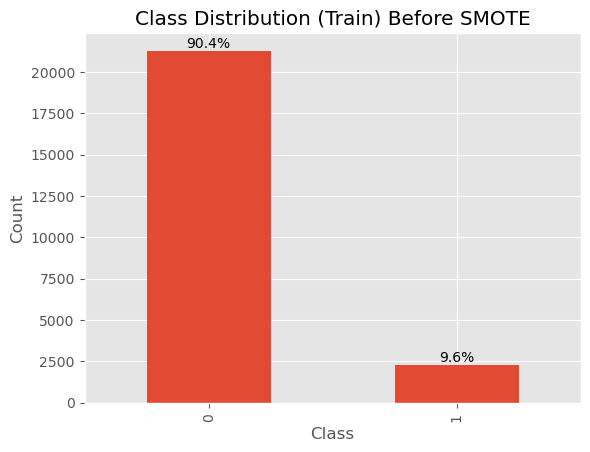

In [35]:
plot_class_balance(y_train,"Class Distribution (Train) Before SMOTE")

## 5. Handling Imbalanced Data

Failures are rare in this dataset, only about 10%. So, the data is highly imbalanced. If we ignore this, the model may simply predict "Healthy" all the time and still achieve high accuracy, which is not useful.

### Approach

We use **SMOTE** to increase the number of failure examples in the training data. Instead of duplicating data, SMOTE creates new synthetic samples based on existing ones.

- We set `sampling_strategy=0.3`, increasing failures from ~10% to ~23%.
- This improves the model’s ability to detect failures without overdoing it.
- We also tried increasing the threshold to higher values. But the model wasn't performing well on the test data.

We also use **class weights** (`scale_pos_weight`) as a secondary step to give more importance to failure cases during training.


In [36]:
# Apply SMOTE on the feature-selected training data.
smote = SMOTE(sampling_strategy=0.3, random_state=SEED)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Training set:")
print(f"\t- before SMOTE : {X_train.shape[0]} samples")
print(f"\t- failures: {y_train.sum():,} = {round(y_train.mean()*100,1)}%")

print(f"Training set:")
print(f"\t- after SMOTE : {X_train_resampled.shape[0]} samples")
print(f"\t- failures: {y_train_resampled.sum()} = {round(y_train_resampled.mean()*100,1)}%)")

Training set:
	- before SMOTE : 23550 samples
	- failures: 2,272 = 9.6%
Training set:
	- after SMOTE : 27661 samples
	- failures: 6383 = 23.1%)


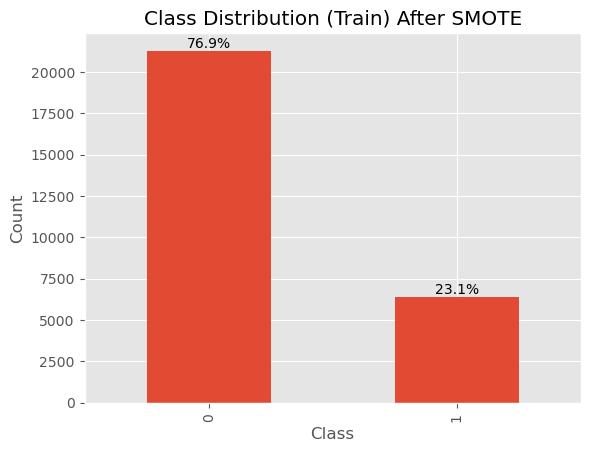

In [37]:
plot_class_balance(y_train_resampled, "Class Distribution (Train) After SMOTE")

**SMOTE has been applied. The resampled training set has a balanced-enough distribution to train on. We can proceed to modeling.**

## 6. Modeling and Benchmarking

We train and compare three models to balance simplicity, performance, and interpretability.

### Models used

- **Logistic Regression:**  
  A simple baseline model. Easy to understand and sets a minimum performance level.

- **Random Forest:**  
  A strong tree-based model that works well on tabular data. It captures complex patterns without much tuning.

- **XGBoost:**  
  An advanced boosting model. It is highly effective for structured data and handles missing values well.

### Evaluation focus

We prioritise **Recall** over Precision, because missing a failure is more costly than raising a false alarm.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, fbeta_score

results = {}

def find_threshold_f2_from_validation_set(model, X_val, y_val):
    # Get candidate thresholds from the precision-recall curve
    y_proba = model.predict_proba(X_val)[:, 1]
    _, _, thresholds = precision_recall_curve(y_val, y_proba)

    best_threshold = 0.5
    best_f2  = 0.0
    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)
        f2 = fbeta_score(y_val, y_pred, beta=2, zero_division=0)
        if f2 > best_f2:
            best_f2 = f2
            best_threshold = thr
    return best_threshold

# Stratified 20% validation split from the original (un-resampled) training set
X_threshold_train, X_threshold_validation, y_threshold_train, y_threshold_validation = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=SEED
)

# Resampled version of the threshold-training split
smote_threshols = SMOTE(sampling_strategy=0.3, random_state=SEED)
X_threshold_train_resampled, y_threshold_train_resampled = smote_threshols.fit_resample(X_threshold_train, y_threshold_train)

In [39]:
# 1. Logistic Regression
print("Training Logistic Regression...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled  = scaler.transform(X_test)

lr_model = LogisticRegression(random_state=SEED, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train_resampled)
y_pred_lr  = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Find F2 threshold using the validation split
lr_threshold_model = LogisticRegression(random_state=SEED, max_iter=1000, class_weight='balanced')
lr_threshold_model.fit(scaler.transform(X_threshold_train_resampled), y_threshold_train_resampled)
lr_threshold = find_threshold_f2_from_validation_set(
    lr_threshold_model,
    scaler.transform(X_threshold_validation),
    y_threshold_validation
)
y_pred_lr = (y_proba_lr >= lr_threshold).astype(int)
print(f"Logistic Regression F2 threshold (val-set): {round(lr_threshold, 4)}")

results['Logistic Regression'] = {
    'Recall': recall_score(y_test, y_pred_lr, zero_division=0),
    'Precision':precision_score(y_test, y_pred_lr, zero_division=0),
    'F1': f1_score(y_test, y_pred_lr, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_proba_lr)
}


Training Logistic Regression...
Logistic Regression F2 threshold (val-set): 0.5103


In [40]:
# 2. Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=20,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
rf_model.fit(X_train_resampled, y_train_resampled)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Fit a lighter RF on the threshold-training split to find F2 threshold
rf_threshold_model = RandomForestClassifier(
    n_estimators=100, max_depth=20,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
rf_threshold_model.fit(X_threshold_train_resampled, y_threshold_train_resampled)
rf_threshold = find_threshold_f2_from_validation_set(rf_threshold_model, X_threshold_validation, y_threshold_validation)
y_pred_rf_opt = (y_proba_rf >= rf_threshold).astype(int)
print(f"Random Forest F2 threshold (val-set): {round(rf_threshold,4)}")

results['Random Forest'] = {
    'Recall':recall_score(y_test, y_pred_rf_opt, zero_division=0),
    'Precision': precision_score(y_test, y_pred_rf_opt, zero_division=0),
    'F1':f1_score(y_test, y_pred_rf_opt, zero_division=0),
    'ROC-AUC':roc_auc_score(y_test, y_proba_rf)
}

Training Random Forest...
Random Forest F2 threshold (val-set): 0.2288


In [41]:
# 3. XGBoost
print("Training XGBoost...")
xgb_pos_weight = (y_train_resampled == 0).sum() / (y_train_resampled == 1).sum()
print(f"scale_pos_weight (post-SMOTE): {round(xgb_pos_weight,2)}")

# Split resampled train data into 90/10 for early-stopping validation
X_xgb_train, X_xgb_es, y_xgb_train, y_xgb_es = train_test_split(
    X_train_resampled, y_train_resampled,
    test_size=0.1, stratify=y_train_resampled, random_state=SEED
)

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    scale_pos_weight=xgb_pos_weight,
    objective='binary:logistic',
    eval_metric='aucpr',
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1
)

xgb_model.fit(X_xgb_train, y_xgb_train,
              eval_set=[(X_xgb_es, y_xgb_es)],
              verbose=False)

print(f"XGBoost best iteration: {xgb_model.best_iteration}")
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Find F2 threshold using the validation split
xgb_threshold_model = xgb.XGBClassifier(
    n_estimators=xgb_model.best_iteration if xgb_model.best_iteration > 0 else 200,
    max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, scale_pos_weight=xgb_pos_weight,
    objective='binary:logistic', random_state=SEED, n_jobs=-1
)

xgb_threshold_model.fit(X_threshold_train_resampled, y_threshold_train_resampled)
xgb_threshold = find_threshold_f2_from_validation_set(xgb_threshold_model, X_threshold_validation, y_threshold_validation)
y_pred_xgb_opt = (y_proba_xgb >= xgb_threshold).astype(int)
print(f"XGBoost F2 threshold (val-set): {round(xgb_threshold,4)}")

results['XGBoost'] = {
    'Recall':    recall_score(y_test, y_pred_xgb_opt, zero_division=0),
    'Precision': precision_score(y_test, y_pred_xgb_opt, zero_division=0),
    'F1':        f1_score(y_test, y_pred_xgb_opt, zero_division=0),
    'ROC-AUC':  roc_auc_score(y_test, y_proba_xgb)
}

Training XGBoost...
scale_pos_weight (post-SMOTE): 3.33
XGBoost best iteration: 499
XGBoost F2 threshold (val-set): 0.25609999895095825


In [42]:
# Display Results
results_df = pd.DataFrame(results).T
print("Model Performance Comparison:")
print(results_df)

Model Performance Comparison:
                       Recall  Precision        F1   ROC-AUC
Logistic Regression  0.302817   0.057487  0.096629  0.626344
Random Forest        0.669014   0.048693  0.090779  0.701979
XGBoost              0.647887   0.057536  0.105686  0.733740


## 7. Evaluation and Visualization

In our case, the standard accuracy is not a useful metric. Because we have only around 3% failures in the test set. So, a model that always predicts "Healthy" would score 97% accuracy while catching zero failures. So we focus on:

- **Recall** — how many actual failures did we catch? This is the most important metric for predictive maintenance.
- **Precision** — of the trucks we flagged, how many were actually failing? This controls false alarms.
- **F1-Score** — the harmonic mean of precision and recall, useful as a single summary number.
- **ROC-AUC** — threshold-independent ranking ability. It tells us how well the model separates failures from healthy trucks overall.

              precision    recall  f1-score   support

 Healthy (0)       0.98      0.86      0.91      4903
 Failure (1)       0.06      0.30      0.10       142

    accuracy                           0.84      5045
   macro avg       0.52      0.58      0.50      5045
weighted avg       0.95      0.84      0.89      5045

              precision    recall  f1-score   support

 Healthy (0)       0.98      0.62      0.76      4903
 Failure (1)       0.05      0.67      0.09       142

    accuracy                           0.62      5045
   macro avg       0.52      0.65      0.43      5045
weighted avg       0.96      0.62      0.74      5045

              precision    recall  f1-score   support

 Healthy (0)       0.99      0.69      0.81      4903
 Failure (1)       0.06      0.65      0.11       142

    accuracy                           0.69      5045
   macro avg       0.52      0.67      0.46      5045
weighted avg       0.96      0.69      0.79      5045



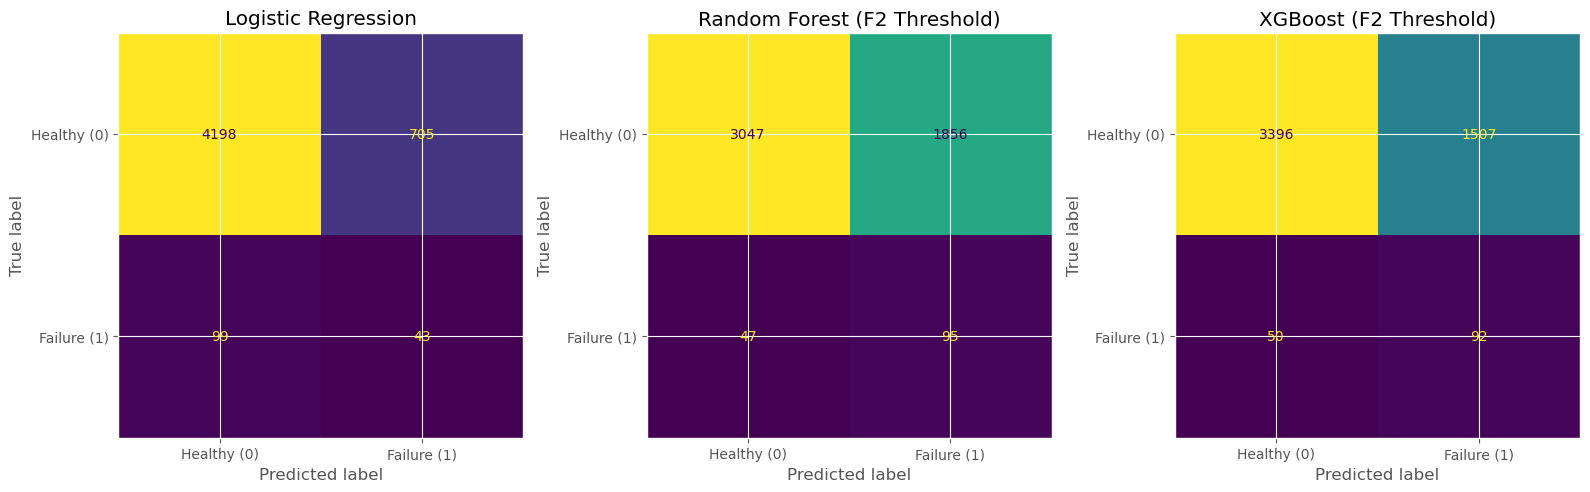

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

class_names = ['Healthy (0)', 'Failure (1)']

# Classification reports for all three models
print(classification_report(y_test, y_pred_lr, target_names=class_names, zero_division=0))
print(classification_report(y_test, y_pred_rf_opt, target_names=class_names, zero_division=0))
print(classification_report(y_test, y_pred_xgb_opt, target_names=class_names, zero_division=0))

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=class_names, ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_opt, display_labels=class_names, ax=axes[1], colorbar=False)
axes[1].set_title('Random Forest (F2 Threshold)')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb_opt, display_labels=class_names, ax=axes[2], colorbar=False)
axes[2].set_title('XGBoost (F2 Threshold)')

plt.tight_layout()
plt.savefig('Plots/confusion_matrices.png', dpi=1200, bbox_inches='tight')
plt.show()


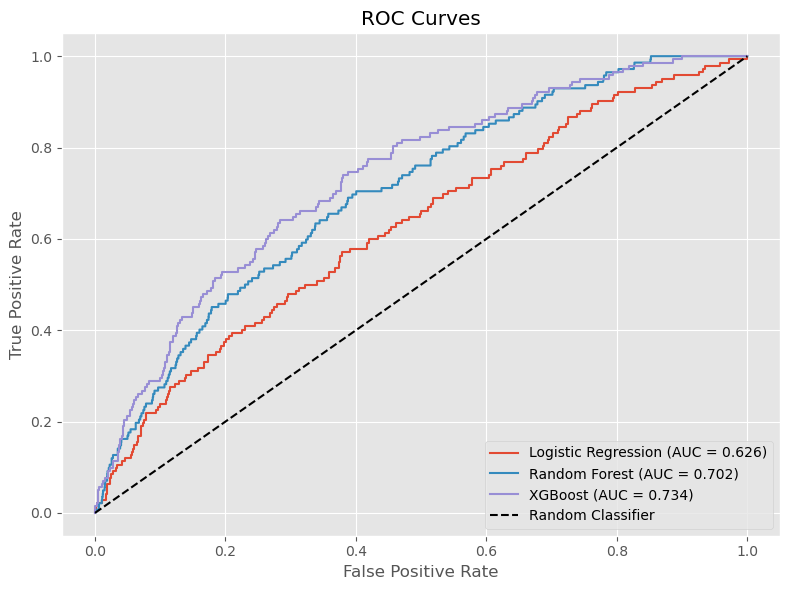

In [44]:
# ROC curves
FPR_lr,  TPR_lr,  _ = roc_curve(y_test, y_proba_lr)
FPR_rf,  TPR_rf,  _ = roc_curve(y_test, y_proba_rf)
FPR_xgb, TPR_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(FPR_lr, TPR_lr, label=f'Logistic Regression (AUC = {round(roc_auc_score(y_test, y_proba_lr),3)})')
plt.plot(FPR_rf, TPR_rf, label=f'Random Forest (AUC = {round(roc_auc_score(y_test, y_proba_rf),3)})')
plt.plot(FPR_xgb, TPR_xgb, label=f'XGBoost (AUC = {round(roc_auc_score(y_test, y_proba_xgb),3)})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('Plots/roc_curves.png', dpi=1200, bbox_inches='tight')
plt.show()

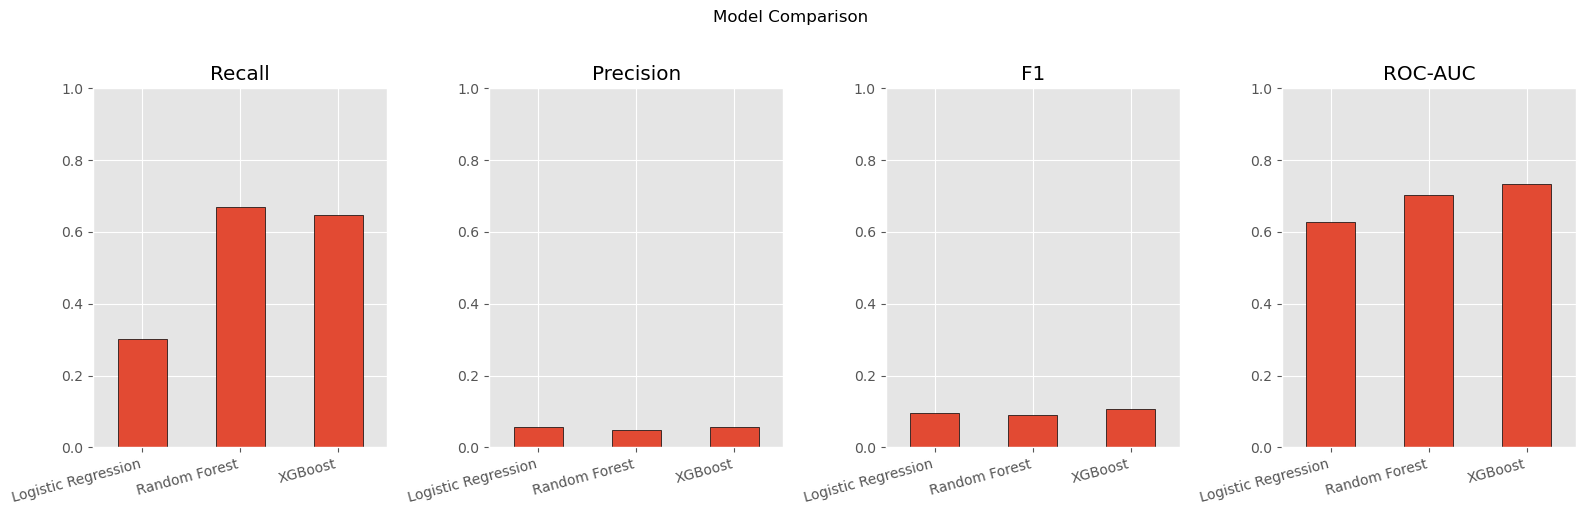

In [45]:
# Bar chart comparison
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

results_df['Recall'].plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Recall')
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(results_df.index, rotation=15, ha='right')

results_df['Precision'].plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('Precision')
axes[1].set_ylim(0, 1)
axes[1].set_xticklabels(results_df.index, rotation=15, ha='right')

results_df['F1'].plot(kind='bar', ax=axes[2], edgecolor='black')
axes[2].set_title('F1')
axes[2].set_ylim(0, 1)
axes[2].set_xticklabels(results_df.index, rotation=15, ha='right')

results_df['ROC-AUC'].plot(kind='bar', ax=axes[3], edgecolor='black')
axes[3].set_title('ROC-AUC')
axes[3].set_ylim(0, 1)
axes[3].set_xticklabels(results_df.index, rotation=15, ha='right')

plt.suptitle('Model Comparison', y=1.02)
plt.tight_layout()
plt.savefig('Plots/model_comparison.png', dpi=1200, bbox_inches='tight')
plt.show()

## 8. Explainability (SHAP)

Explainability of the predictions is the other major aspect of the research question of this project. For that, we are employing SHAP (SHapley Additive exPlanations). It is a **local, model-agnostic** explainability method. It works by sampling different subsets (coalitions) of features, collecting model predictions for each subset, assigning weights, and fitting a weighted linear model to extract a Shapley value for each feature. The Shapley value tells us how much a given feature contributed to the prediction for a specific sample. A positive value pushes toward failure, and a negative value pushes toward healthy.

This is the most important part of the study for answering the research question. We argue that XGBoost with SHAP is preferable to a black-box LSTM because a maintenance engineer can actually see *why* a truck was flagged. We used two visualisations:

- **Beeswarm plot** — shows the global distribution of SHAP values across all test trucks. The x-axis is the SHAP value, each dot is one truck, and colour shows the feature's raw value.
- **Force/Waterfall plots** — a local explanation for a single truck. Each bar shows one feature's contribution, starting from the baseline prediction and building up to the final output.
- **Dependence plots** — show how the SHAP value of a feature changes as its raw value changes, which helps identify non-linear thresholds.

In [46]:
# Compute SHAP values using TreeExplainer
shap_explainer = shap.TreeExplainer(xgb_model)
shap_values = shap_explainer.shap_values(X_test)

# Also build an Explanation object that will be needed for waterfall plots later
shap_explanation = shap.Explanation(
    values = shap_values,
    base_values = shap_explainer.expected_value,
    data = X_test.values,
    feature_names = X_test.columns.tolist()
)

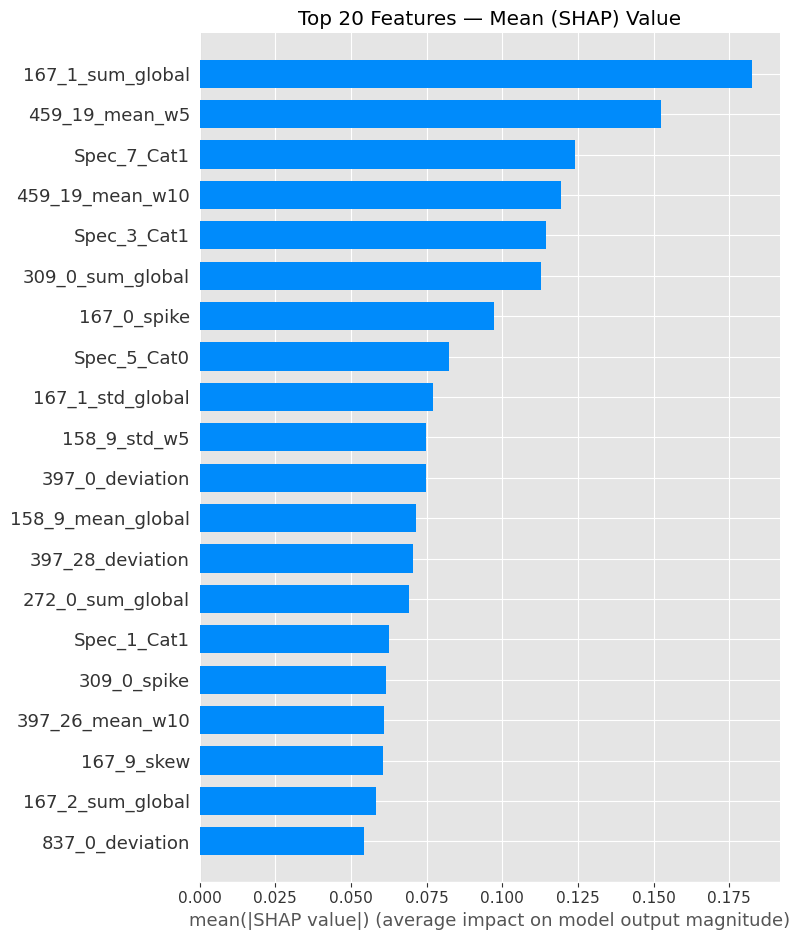

In [47]:
# Plot a bar chart that shows global feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20, show=False)
plt.title("Top 20 Features — Mean (SHAP) Value")
plt.tight_layout()
plt.savefig("Plots/shap_bar_importance.png", dpi=1200, bbox_inches="tight")
plt.show()

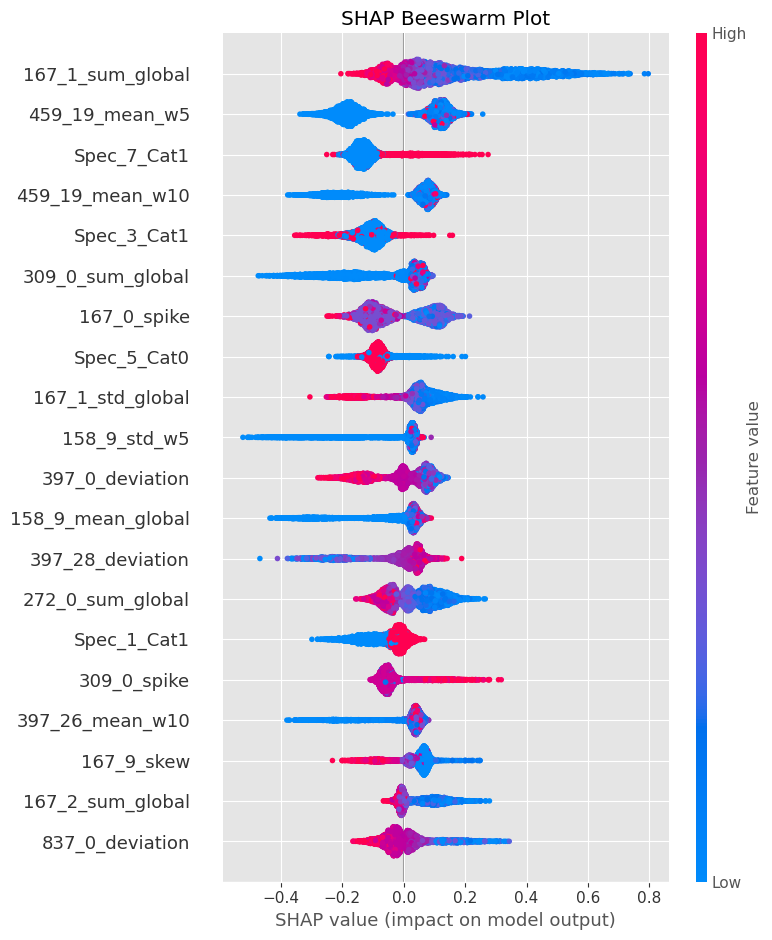

In [48]:
# Plot Beeswarm plot that shows direction and magnitude for each sample
# In the plot, Red = high feature value, Blue = low feature value
plt.figure()
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.savefig("Plots/shap_beeswarm.png", dpi=1200, bbox_inches="tight")
plt.show()

In [49]:
# Print the top 20 features by mean (SHAP) for reference
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test.columns).sort_values(ascending=False)
print("Top 20 features by mean (SHAP) value:")
print(mean_abs_shap.head(20).to_string())

Top 20 features by mean (SHAP) value:
167_1_sum_global     0.182614
459_19_mean_w5       0.152542
Spec_7_Cat1          0.124072
459_19_mean_w10      0.119525
Spec_3_Cat1          0.114412
309_0_sum_global     0.112628
167_0_spike          0.097275
Spec_5_Cat0          0.082324
167_1_std_global     0.077192
158_9_std_w5         0.074901
397_0_deviation      0.074849
158_9_mean_global    0.071399
397_28_deviation     0.070595
272_0_sum_global     0.069259
Spec_1_Cat1          0.062580
309_0_spike          0.061580
397_26_mean_w10      0.060913
167_9_skew           0.060708
167_2_sum_global     0.058390
837_0_deviation      0.054440


### 8.1 Local Explanations — Waterfall (Force) Plots

The beeswarm plot gives a global view, but SHAP is also a **local** method. It can explain a single prediction. This is the most useful output for a maintenance engineer who wants to know why a specific truck was flagged.

The waterfall plot starts at the baseline prediction `E[f(X)]`, which is the model's average output. Then, it adds or subtracts each feature's contribution until it reaches the final prediction `f(x)`. Features in red push toward failure, and features in blue push toward healthy.

We show two examples: 
- the highest-confidence true positive (a real failure the model was most certain about) and
- a typical healthy truck.

In [50]:
y_test_arr  = np.array(y_test)
y_proba_arr = np.array(y_proba_xgb)

# Find the highest-confidence true positive
TP_indices = np.where((y_test_arr == 1) & (y_proba_arr >= xgb_threshold))[0]
if len(TP_indices) == 0:
    TP_indices = np.where(y_test_arr == 1)[0]
best_TP = TP_indices[np.argmax(y_proba_arr[TP_indices])]

print(f"True Positive — Test index {best_TP}")
print(f"Predicted probability : {round(y_proba_arr[best_TP],4)}  (threshold = {round(xgb_threshold,4)}")
print(f"Actual label          : FAILURE\n")


True Positive — Test index 1231
Predicted probability : 0.9509999752044678  (threshold = 0.25609999895095825
Actual label          : FAILURE



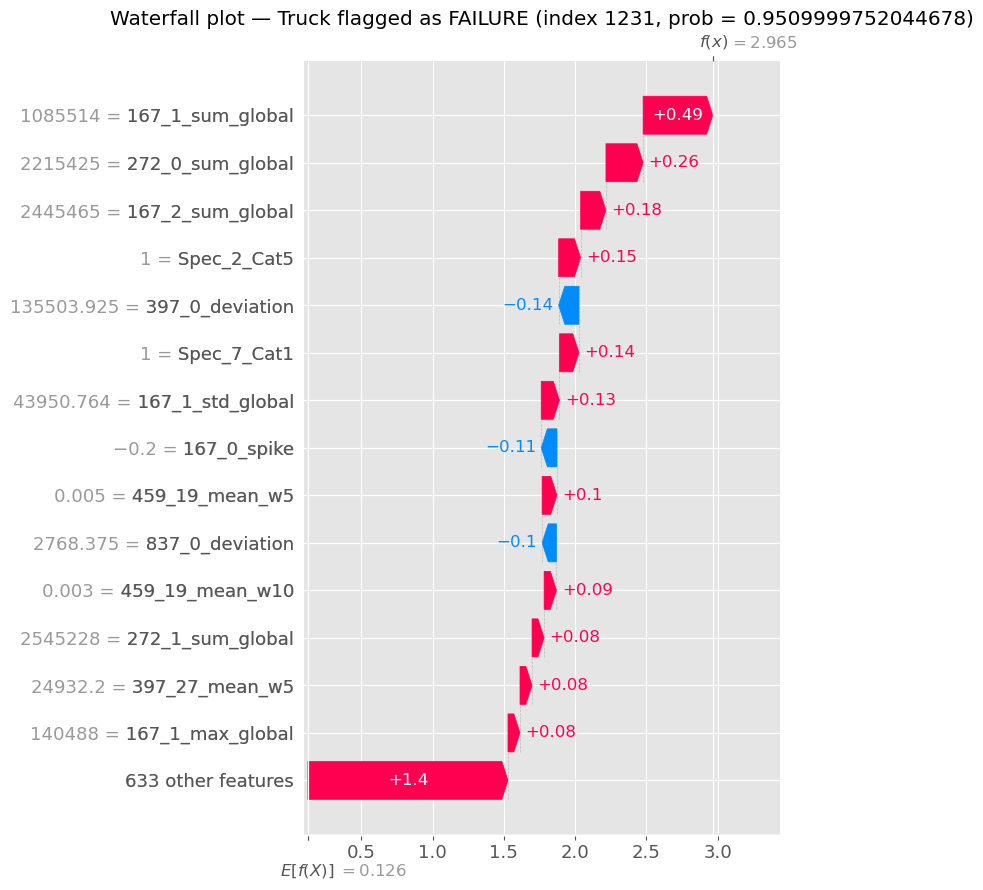

In [51]:
plt.figure()
shap.plots.waterfall(shap_explanation[best_TP], max_display=15, show=False)
plt.title(f"Waterfall plot — Truck flagged as FAILURE (index {best_TP}, prob = {round(y_proba_arr[best_TP],3)})")
plt.tight_layout()
plt.savefig("Plots/shap_waterfall_failure.png", dpi=1200, bbox_inches="tight")
plt.show()


In [52]:
# Find a typical healthy truck (lowest predicted probability)
TN_indices = np.where((y_test_arr == 0) & (y_proba_arr < xgb_threshold))[0]
if len(TN_indices) == 0:
    TN_indices = np.where(y_test_arr == 0)[0]
best_TN = TN_indices[np.argmin(y_proba_arr[TN_indices])]

print(f"True Negative — Test index {best_TN}")
print(f"Predicted probability : {round(y_proba_arr[best_TN],4)}  (threshold = {round(xgb_threshold,4)})")
print(f"Actual label          : HEALTHY\n")

True Negative — Test index 4090
Predicted probability : 0.0003000000142492354  (threshold = 0.25609999895095825)
Actual label          : HEALTHY



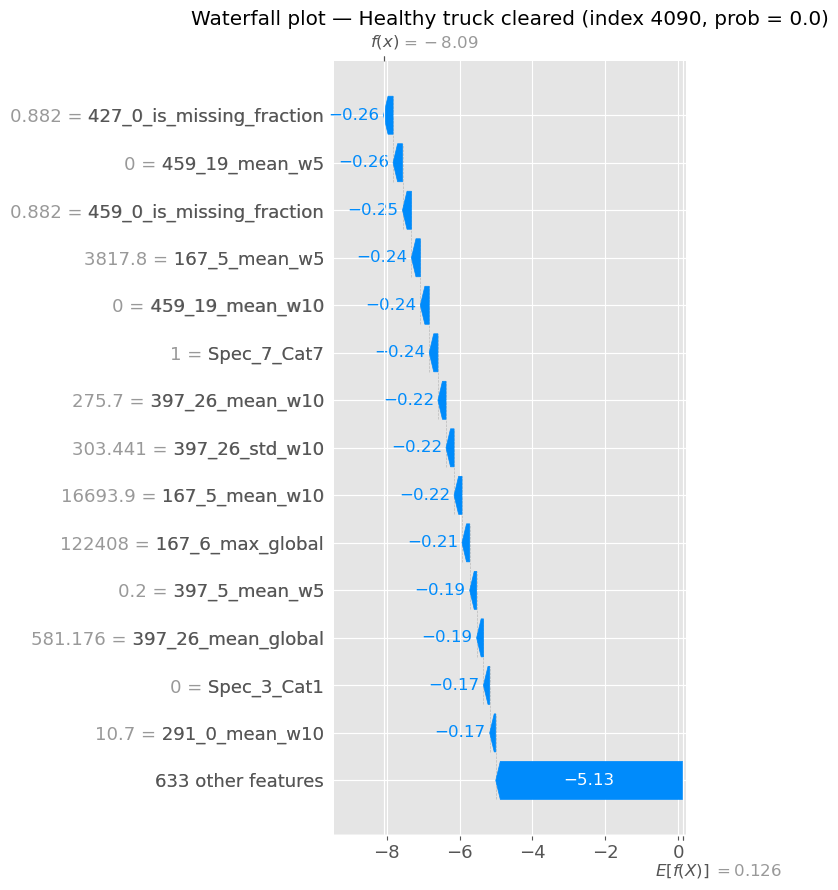

In [53]:
plt.figure()
shap.plots.waterfall(shap_explanation[best_TN], max_display=15, show=False)
plt.title(f"Waterfall plot — Healthy truck cleared (index {best_TN}, prob = {round(y_proba_arr[best_TN],3)})")
plt.tight_layout()
plt.savefig("Plots/shap_waterfall_healthy.png", dpi=1200, bbox_inches="tight")
plt.show()

### 8.2 Feature Dependence Plots

A dependence plot is similar in spirit to a Partial Dependence Plot (PDP). It shows how a single feature's value relates to its impact on the model's output. The difference is that dependence plots show SHAP values directly, so each point is one truck rather than an average.

The colour of each point is automatically set by SHAP to the feature it interacts with most.

We plot the top 3 features by global importance.

Top 3 features: ['167_1_sum_global', '459_19_mean_w5', 'Spec_7_Cat1']



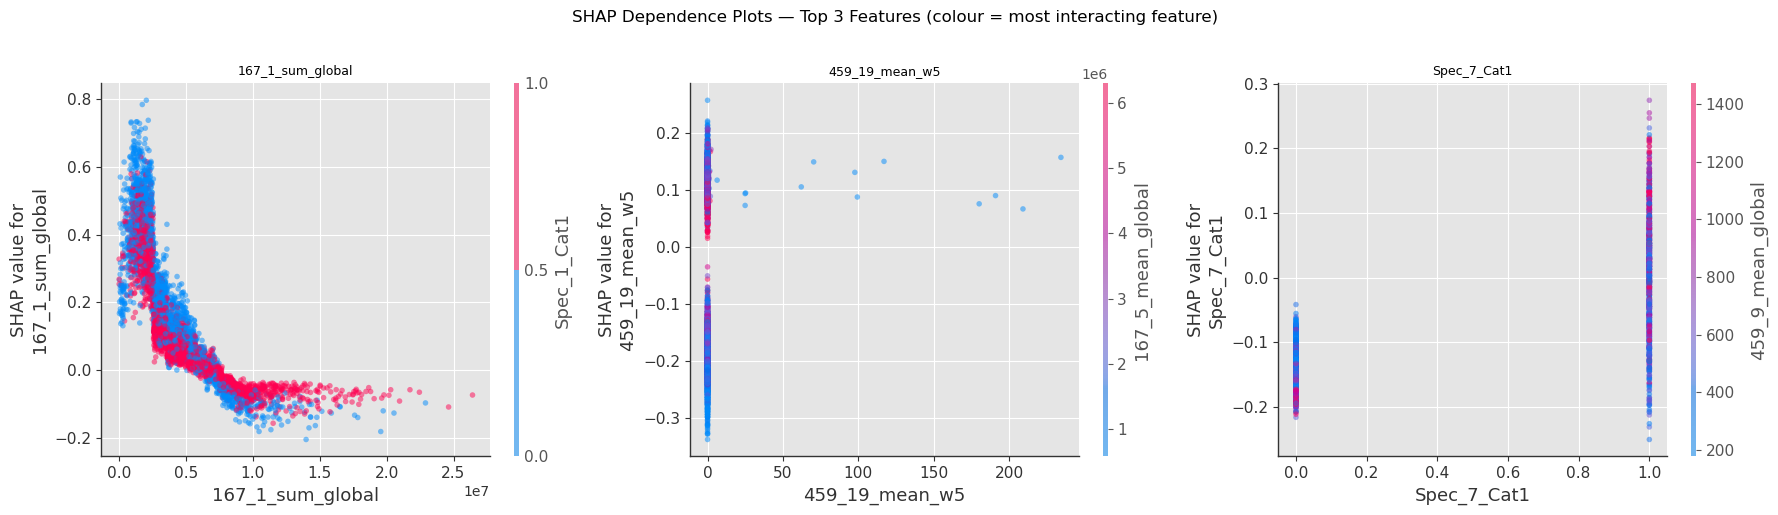

In [54]:
top3_features = mean_abs_shap.head(3).index.tolist()
print(f"Top 3 features: {top3_features}\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feature in zip(axes, top3_features):
    shap.dependence_plot(feature, shap_values, X_test, ax=ax, show=False, alpha=0.5)
    ax.set_title(feature, fontsize=9)

plt.suptitle("SHAP Dependence Plots — Top 3 Features (colour = most interacting feature)", y=1.02)
plt.tight_layout()
plt.savefig("Plots/shap_dependence_top3.png", dpi=1200, bbox_inches="tight")
plt.show()